In [2]:
import sys
sys.path.append('/home/r/Robert.Reichert/sexy-wave/Reichert_2026_publication')
import AMTM_related
sys.path.append('/home/r/Robert.Reichert/sexy-wave')
import plotting_cosmetics as pc
sys.path.append('/home/r/Robert.Reichert/artsy-colors')
import create_cmaps as cc
from gold_white_blue_matplotlib import get_cmap

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.colors as mcolors

import pylops 

plt.style.use("../latex_default_AMT.mplstyle")

In [3]:
data_path = '/project/meteo/work/Robert.Reichert/data/AMTM/Rio_Grande/2018/201805/AMTM_BI_20180516-2137.nc'
ds = xr.open_dataset(data_path)

BI = ds['band intensity'].isel(time=slice(100,260),x=slice(3,-40),y=slice(35,-42))
BI_high = BI.values
BI_high=np.flip(BI_high,axis=0)
for i in range(BI['time'].size):
    BI_high[:,:,i], _ = AMTM_related.AMTM_filter(BI_high[:,:,i])

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [4]:
dx, dy, dt = 625, 625, 35
nx, ny, nt = BI['y'].size, BI['x'].size, BI['time'].size
print(nx, ny, nt)

nmask = (ny, nx, nt)
ntap = (20,20,5)
tap3d = pylops.utils.tapers.tapernd(nmask, ntap, "hanning")
airglow = BI_high*tap3d

243 213 160


In [5]:
nlc = cc.jpg2cmap('/home/r/Robert.Reichert/artsy-colors/jpgs/NLC.jpg',51,cmap=True,allow_discontinuities=False,discrete_colors=False)

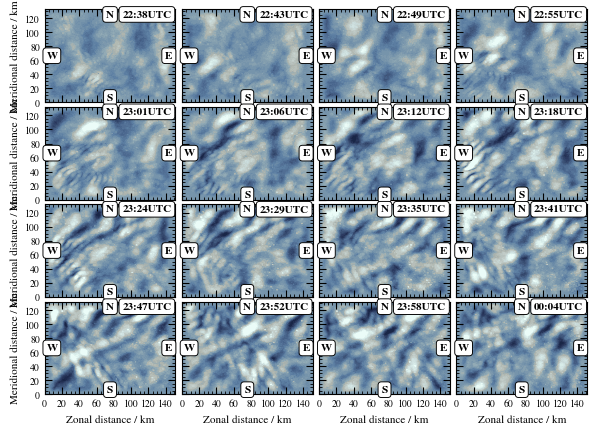

In [7]:
BI_lev = np.linspace(-4000,4000,51)
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3

gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1, 1, 1, 1], "height_ratios": [1, 1, 1, 1]}

time_indexes=np.linspace(5,155,16)
fig, ax=plt.subplots(4,4, figsize=(7,5), gridspec_kw=gskw,sharex=True, sharey=True)

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        ax[i,j].contourf(x,y,airglow[:,:,int(time_indexes[i*ax.shape[1]+j])],levels=BI_lev,extend='both',cmap=nlc)

yl = ['Meridional distance / km','','','','Meridional distance / km','','','',
     'Meridional distance / km','','','','Meridional distance / km','','','']
xl = ['','','','','','','','','','','','',
      'Zonal distance / km','Zonal distance / km','Zonal distance / km','Zonal distance / km']

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        ax[i,j].set_ylabel(yl[i*ax.shape[1]+j])
        ax[i,j].set_xlabel(xl[i*ax.shape[1]+j])
        ax[i,j].yaxis.set_major_locator(MultipleLocator(20))
        ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())
        ax[i,j].xaxis.set_major_locator(MultipleLocator(20))
        ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())
        #ax[i,j].tick_params(which='both', labelbottom=True, labeltop=False)
        ax[i,j].grid()
        ax[i,j].text(0.5, 0.945, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.5, 0.05, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.055, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.95, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.97, 0.945, str(BI['time'].isel(time=int(time_indexes[i*ax.shape[1]+j])).values)[11:16]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

#ax[1,0].tick_params(labelbottom=False)
#ax[1,1].tick_params(labelbottom=False)
#ax[1,2].tick_params(labelbottom=False)

plt.savefig('./figures/AMTM_overview.png', dpi=300, bbox_inches="tight", pad_inches=0.03)